In [1]:
from pathlib import Path
import sys

HERE = Path.cwd().resolve()

for base in [HERE, *HERE.parents]:
    pkg_dir = base / "src" / "marketplace_signature_forecast"
    if pkg_dir.exists():
        sys.path.insert(0, str(base / "src"))
        break
else:
    raise ModuleNotFoundError(
        f"Could not find 'src/marketplace_signature_forecast' from {HERE}"
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("cwd:", Path.cwd().resolve())
print("sys.path[0]:", sys.path[0])
print("exists:", Path(sys.path[0], "marketplace_signature_forecast").exists())
print("config exists:", Path(sys.path[0], "marketplace_signature_forecast", "config.py").exists())
from marketplace_signature_forecast.config import (
    ALL_HORIZONS,
    DATA_DIR,
    DEFAULT_DEPTH,
    DEFAULT_N_TARGET,
    DEFAULT_WINDOW_SIZE,
    END_DATE,
    FIGURES_DIR,
    FRED_API_KEY,
    N_VALIDATION,
    START_DATE,
    TARGET,
    ensure_directories,
)
from marketplace_signature_forecast.adaptive_weights import pick_gamma_by_neff, rolling_adaptive_weights
from marketplace_signature_forecast.baselines import compute_relative_error
from marketplace_signature_forecast.data_loading import build_data_dictionary, fetch_marketplace_series
from marketplace_signature_forecast.evaluation import (
    build_forecast_dataframe,
    compare_with_baselines,
    inverse_transform_forecasts,
    run_multi_horizon_experiment,
)
from marketplace_signature_forecast.modeling import rolling_forecast
from marketplace_signature_forecast.plotting import (
    plot_adaptive_weight_diagnostics,
    plot_correlation_matrix,
    plot_forecast_vs_actual,
    plot_input_grid,
    plot_target_split,
    plot_weights_for_origin,
)
from marketplace_signature_forecast.preprocessing import (
    build_model_dataset,
    prepare_standardized_arrays,
    resample_collection,
    resample_to_weekly,
    save_processed_bundle,
    train_validation_split,
)

ensure_directories()
np.random.seed(42)

cwd: C:\Users\tsito\OneDrive\Documents\Imperial\Data Challenges and Github\signature-forecasting-market-rates\notebooks
sys.path[0]: C:\Users\tsito\OneDrive\Documents\Imperial\Data Challenges and Github\signature-forecasting-market-rates\src
exists: True
config exists: True


## 1. Data download and preprocessing

In [2]:
y_raw, x_raw = fetch_marketplace_series(FRED_API_KEY, START_DATE, END_DATE)
y_weekly = resample_to_weekly(y_raw)
x_weekly = resample_collection(x_raw)
full_data = build_model_dataset(y_weekly, x_weekly)
train_data, validation_data = train_validation_split(full_data, N_VALIDATION)
data_dictionary = build_data_dictionary()

save_processed_bundle(full_data, train_data, validation_data, data_dictionary, DATA_DIR)

print(full_data.shape)
full_data.head()

(365, 10)


,consumer_loans,sp500,bank_credit,gas_price,loans_leases,securities,ovx,wti_crude,brent_crude,amazon_stock
date,,,,,,,,,,
2018-01-03,767.8695,2713.06,12565.5385,2.520,9126.9922,3438.5462,22.75,61.61,67.85,60.209999
2018-01-10,768.5149,2748.23,12562.5932,2.522,9132.8667,3429.7264,23.52,63.60,69.79,62.716499
2018-01-17,769.6011,2802.56,12570.4123,2.557,9145.0310,3425.3813,24.78,63.92,69.19,64.750000
2018-01-24,767.3849,2837.54,12573.2215,2.567,9146.0674,3427.1541,23.93,65.69,69.91,67.875504
2018-01-31,769.3092,2823.81,12578.5406,2.607,9154.8997,3423.6409,22.23,64.82,67.78,72.544502


## 2. Exploratory analysis

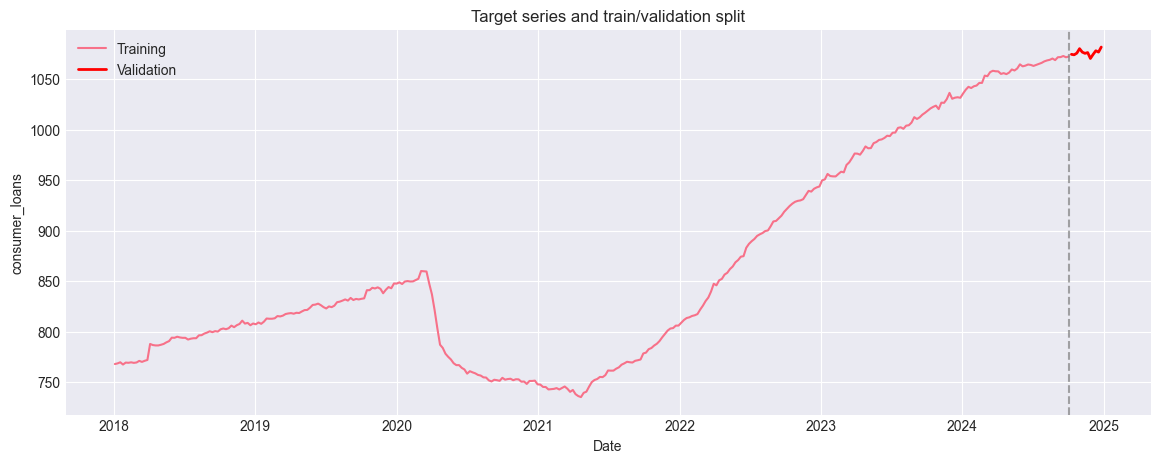

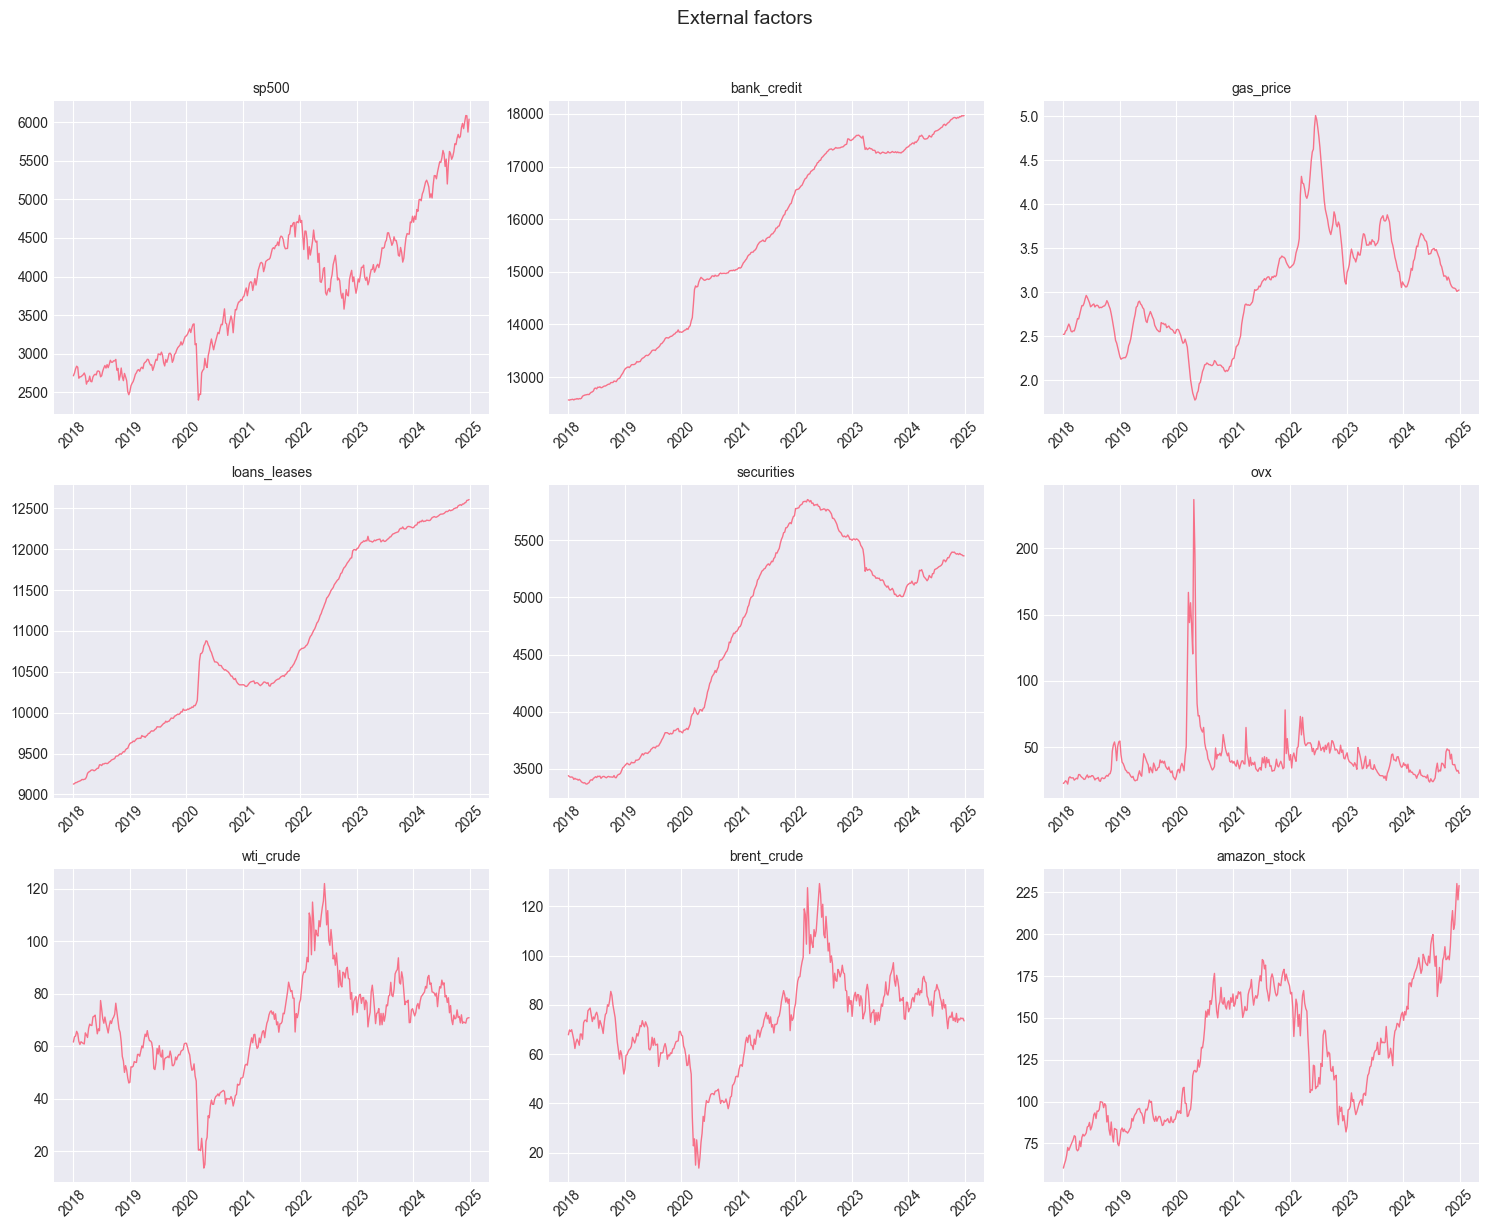

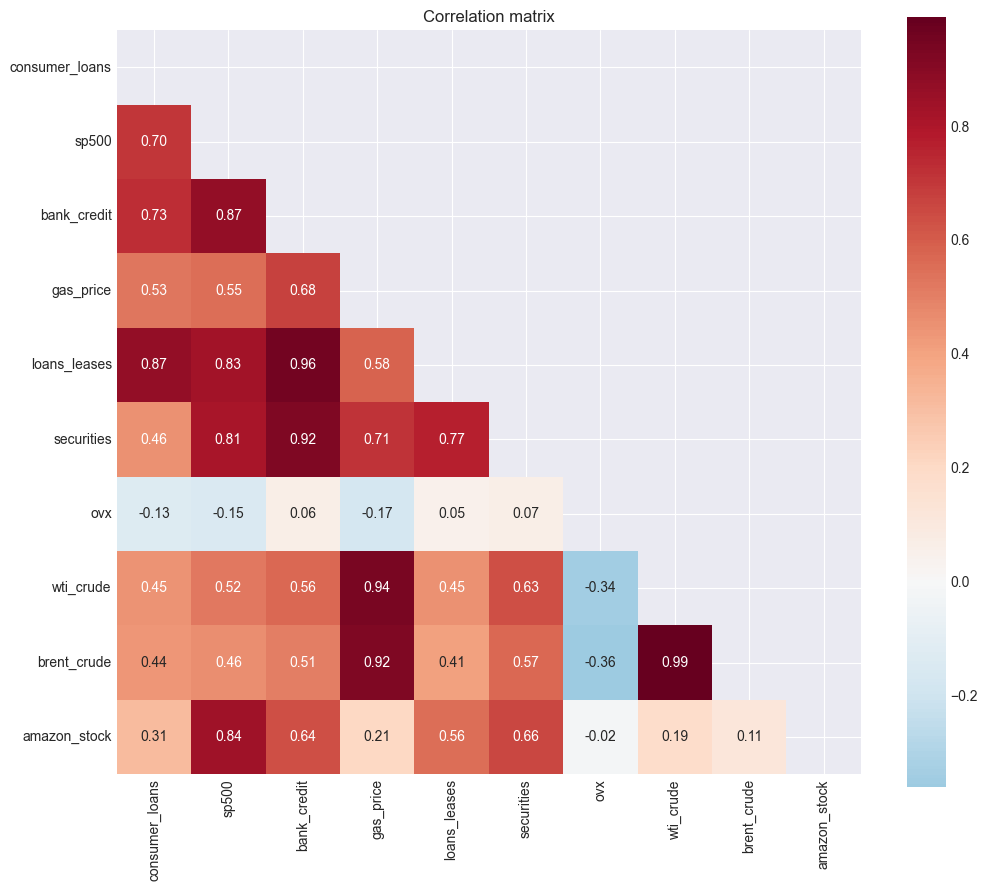

,consumer_loans,sp500,bank_credit,gas_price,loans_leases,securities,ovx,wti_crude,brent_crude,amazon_stock
count,365.00,365.00,365.00,365.00,365.00,365.00,365.00,365.00,365.00,365.00
mean,871.66,3848.97,15542.39,3.04,10860.67,4681.72,41.04,68.31,73.03,129.20
std,110.10,917.89,1830.47,0.62,1095.50,847.91,21.52,18.01,18.82,38.92
min,735.15,2398.10,12562.59,1.77,9126.99,3364.77,22.23,13.64,13.77,60.21
25%,786.15,2926.46,13746.77,2.58,9932.49,3808.39,30.76,56.92,63.61,92.77
50%,829.07,3909.88,15628.01,3.03,10576.96,5061.65,36.79,69.30,74.25,126.77
75%,975.10,4456.24,17325.98,3.45,12095.54,5373.85,45.12,78.91,83.33,163.26
max,1081.58,6086.49,17970.26,5.01,12605.75,5857.94,236.80,121.94,129.20,230.26


In [3]:
plot_target_split(train_data, validation_data, TARGET['name'], FIGURES_DIR / 'target_variable.png')
plot_input_grid(full_data, TARGET['name'], FIGURES_DIR / 'input_variables.png')
plot_correlation_matrix(full_data, FIGURES_DIR / 'correlation_matrix.png')

full_data.describe().round(2)

## 3. Standardized modeling arrays

In [4]:
prepared = prepare_standardized_arrays(
    full_data=full_data,
    target_col=TARGET['name'],
    horizons=ALL_HORIZONS,
    n_validation=N_VALIDATION,
)

X = prepared['X']
y = prepared['y']
y_raw_array = prepared['y_raw']
dates = prepared['dates']
y_scaler = prepared['y_scaler']
train_end_t = prepared['train_end']

WINDOW_SIZE = DEFAULT_WINDOW_SIZE
DEPTH = DEFAULT_DEPTH
N_TARGET = DEFAULT_N_TARGET
DELTA_T = 12


## 4. Adaptive-weight diagnostics

In [ ]:
min_t = WINDOW_SIZE + DELTA_T + 20
adaptive_results = rolling_adaptive_weights(
    X=X,
    y=y,
    start_t=min_t,
    end_t=train_end_t,
    delta_t=DELTA_T,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    gamma=None,
    n_target=N_TARGET,
    add_time=True,
)

plot_adaptive_weight_diagnostics(adaptive_results, dates, y, train_end_t, N_TARGET, TARGET['name'])
plot_weights_for_origin(adaptive_results, len(adaptive_results['t']) // 2, X, y, dates, DELTA_T, WINDOW_SIZE, DEPTH)

## 5. Single-horizon rolling forecast (12 weeks)

In [ ]:
val_start_t = len(y) - N_VALIDATION - DELTA_T
val_end_t = len(y) - DELTA_T - 1

forecast_results = rolling_forecast(
    X=X,
    y=y,
    start_t=val_start_t,
    end_t=val_end_t,
    delta_t=DELTA_T,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    lambda_lasso=None,
    gamma=None,
    n_target=N_TARGET,
    use_sig_y_only=True,
    add_time=True,
)

single_horizon_metrics = inverse_transform_forecasts(forecast_results, y_scaler)
single_horizon_df = build_forecast_dataframe(forecast_results, dates, DELTA_T, single_horizon_metrics)
single_horizon_df.to_csv(DATA_DIR / f'forecast_results_delta{DELTA_T}.csv', index=False)

print({k: v for k, v in single_horizon_metrics.items() if k in ['mae', 'rmse', 'mre', 'median_re']})
plot_forecast_vs_actual(single_horizon_df, DELTA_T)
single_horizon_df.head()

## 6. Multi-horizon signature experiment

In [ ]:
multi_horizon_results, signature_summary = run_multi_horizon_experiment(
    X=X,
    y=y,
    dates=dates,
    y_scaler=y_scaler,
    horizons=ALL_HORIZONS,
    n_validation=N_VALIDATION,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    n_target=N_TARGET,
    output_dir=DATA_DIR,
    lambda_lasso=None,
    gamma=None,
    use_sig_y_only=True,
    add_time=True,
)

signature_summary

## 7. Baseline comparison

In [ ]:
comparison_table = compare_with_baselines(
    y_raw=y_raw_array,
    horizons=ALL_HORIZONS,
    n_validation=N_VALIDATION,
    signature_summary=signature_summary,
)

comparison_table.to_csv(DATA_DIR / 'table_a3_full_comparison.csv', index=False)
comparison_table